In [ ]:
!pip install google-cloud-bigquery pandas-gbq xgboost scikit-learn matplotlib seaborn shap -q

In [ ]:
#Imports

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
import xgboost as xgb

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
#BigQuery Connection

from google.colab import auth
auth.authenticate_user()

print("✓ Authentication successful")

✓ Authentication successful


In [ ]:
# UPDATE THESE WITH YOUR VALUES
PROJECT_ID = 'end-to-end-de-project-485511'
DATASET_NAME = 'transformed_data_analytics'
TABLE_NAME = 'dim_customers'

# Model parameters
TARGET_COLUMN = 'is_churned'
TEST_SIZE = 0.2
RANDOM_STATE = 42
VALIDATION_SIZE = 0.2

print(f"Configuration:")
print(f"  Project: {PROJECT_ID}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Table: {TABLE_NAME}")
print(f"  Target: {TARGET_COLUMN}")

Configuration:
  Project: end-to-end-de-project-485511
  Dataset: transformed_data_analytics
  Table: dim_customers
  Target: is_churned


In [ ]:
print("Loading data from BigQuery...")

client = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_NAME}.{TABLE_NAME}`
"""

df = client.query(query).to_dataframe()

print(f"✓ Loaded {len(df)} rows and {len(df.columns)} columns")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nTarget variable distribution:")
print(df[TARGET_COLUMN].value_counts())
print(f"\nChurn rate: {df[TARGET_COLUMN].mean():.2%}")

Loading data from BigQuery...
✓ Loaded 9785 rows and 21 columns

Dataset shape: (9785, 21)

First few rows:
   customer_id  orders_per_month     total_spent avg_item_value  \
0           21              0.66  1627.500000000  125.192307692   
1           66              0.42  2005.040000000  154.233846154   
2          110              0.69  2083.310000000  160.254615385   
3          280              0.69  1719.880000000  132.298461538   
4          360              0.78  1999.840000000  117.637647059   

  max_item_value  stddev_item_value  unique_products_purchased  \
0  227.510000000          64.939162                         13   
1  271.200000000          93.333011                         13   
2  295.990000000          95.981752                         13   
3  298.790000000         108.025141                         13   
4  274.230000000          84.773850                         17   

  avg_product_rating highest_product_rating lowest_product_rating  ...  \
0        2.1461538


DATA EXPLORATION

Summary Statistics:
       customer_id  orders_per_month  stddev_item_value  \
count       9785.0       9785.000000        9785.000000   
mean   4993.301891          0.471377          65.802557   
std    2887.025169          0.571572          40.369524   
min            1.0          0.080000           0.000000   
25%         2491.0          0.290000          36.787159   
50%         4991.0          0.420000          74.261566   
75%         7491.0          0.550000          94.160187   
max        10000.0         30.000000         201.108240   

       unique_products_purchased  successful_orders  canceled_orders  \
count                     9785.0             9785.0           9785.0   
mean                    4.272969           2.293817         0.117936   
std                     2.858797           1.450825         0.340431   
min                          0.0                0.0              0.0   
25%                          2.0                1.0              0.0 

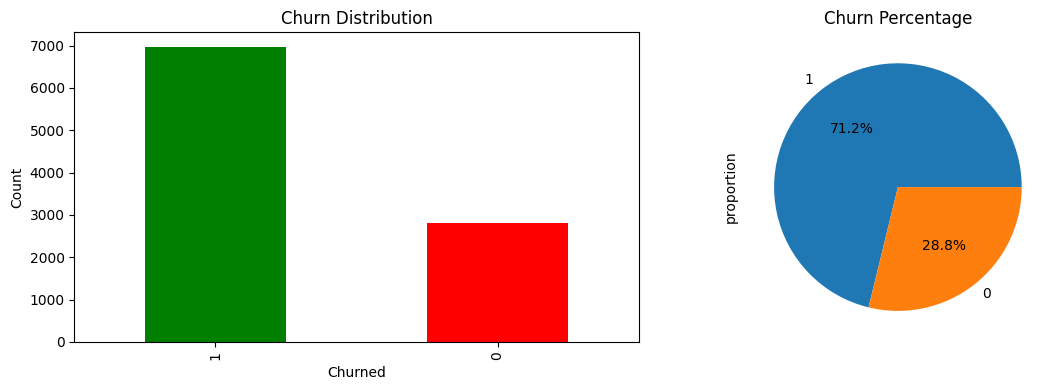

In [ ]:
print("\n" + "="*70)
print("DATA EXPLORATION")
print("="*70)

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Churn by country (if categorical features available)
if 'country' in df.columns:
    print("\nChurn Rate by Country:")
    print(df.groupby('country')[TARGET_COLUMN].agg(['count', 'sum', 'mean']).round(3))

if 'gender' in df.columns:
    print("\nChurn Rate by Gender:")
    print(df.groupby('gender')[TARGET_COLUMN].agg(['count', 'sum', 'mean']).round(3))

# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[TARGET_COLUMN].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Churn Distribution')
axes[0].set_xlabel('Churned')
axes[0].set_ylabel('Count')

df[TARGET_COLUMN].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*70)
print("DATA CLEANING AND PREPROCESSING")
print("="*70)

# Print no. of rows befor eremoving missing target rows
print(f"Before removing missing target: {len(df)} rows")
# Remove rows with missing target
df = df.dropna(subset=[TARGET_COLUMN])
print(f"After removing missing target: {len(df)} rows")

# Identify feature and target columns
exclude_cols = ['customer_id', TARGET_COLUMN]
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df[TARGET_COLUMN].copy()

print(f"\nFeatures ({len(X.columns)}): {feature_cols}")
print(f"Target: {TARGET_COLUMN}")

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Handle missing values in numeric columns
for col in numeric_cols:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)
        print(f"Filled {col} with median")

# Handle infinite values in temporal features
temporal_features = ['avg_days_between_orders', 'stddev_days_between_orders',
                     'order_interval_entropy', 'order_regularness_score']
for col in temporal_features:
    if col in numeric_cols:
        # Replace infinite values with 0
        X[col].replace([np.inf, -np.inf], 0, inplace=True)
        print(f"Replaced infinite values in {col}")

# Handle missing values in categorical columns
for col in categorical_cols:
    if X[col].isnull().any():
        X[col].fillna('Unknown', inplace=True)
        print(f"Filled {col} with 'Unknown'")

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}")

print(f"\n✓ Data cleaning complete")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Infinite values in X: {np.isinf(X).sum().sum()}")


DATA CLEANING AND PREPROCESSING
Before removing missing target: 9785 rows
After removing missing target: 9785 rows

Features (19): ['orders_per_month', 'total_spent', 'avg_item_value', 'max_item_value', 'stddev_item_value', 'unique_products_purchased', 'avg_product_rating', 'highest_product_rating', 'lowest_product_rating', 'successful_orders', 'canceled_orders', 'cancellation_rate', 'country', 'city', 'gender', 'avg_days_between_orders', 'stddev_days_between_orders', 'order_interval_entropy', 'order_regularness_score']
Target: is_churned

Numeric features (10): ['orders_per_month', 'stddev_item_value', 'unique_products_purchased', 'successful_orders', 'canceled_orders', 'cancellation_rate', 'avg_days_between_orders', 'stddev_days_between_orders', 'order_interval_entropy', 'order_regularness_score']
Categorical features (9): ['total_spent', 'avg_item_value', 'max_item_value', 'avg_product_rating', 'highest_product_rating', 'lowest_product_rating', 'country', 'city', 'gender']
Replaced

In [ ]:
churn_counts = y.value_counts().sort_index()
churn_percentages = y.value_counts(normalize=True).sort_values(ascending=False) * 100

print("\nChurn Distribution:")
print(f"  Active (0): {churn_counts[0]:,} customers ({churn_percentages[0]:.2f}%)")
print(f"  Churned (1): {churn_counts[1]:,} customers ({churn_percentages[1]:.2f}%)")

print(f"\nTotal Customers: {len(y):,}")


Churn Distribution:
  Active (0): 2,819 customers (28.81%)
  Churned (1): 6,966 customers (71.19%)

Total Customers: 9,785


In [ ]:
print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))

print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


TRAIN-TEST SPLIT
Training set: (7828, 19)
Test set: (1957, 19)

Training set class distribution:
is_churned
1    0.711932
0    0.288068
Name: proportion, dtype: Float64

Test set class distribution:
is_churned
1    0.711804
0    0.288196
Name: proportion, dtype: Float64


In [ ]:
print("\n" + "="*70)
print("FEATURE SCALING")
print("="*70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for XGBoost
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✓ Features scaled using StandardScaler")


FEATURE SCALING
✓ Features scaled using StandardScaler


In [ ]:
print("\n" + "="*70)
print("TRAINING BASE XGBOOST MODEL")
print("="*70)

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)

print("Training model...")
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    #early_stopping_rounds=10,
    verbose=False
)

print("✓ Model trained successfully")


TRAINING BASE XGBOOST MODEL
Training model...
✓ Model trained successfully


In [ ]:
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  F1-Score: {f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


MODEL EVALUATION

Model Performance:
  Accuracy: 0.9566
  ROC-AUC: 0.9913
  F1-Score: 0.9692

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.95      0.93       564
         1.0       0.98      0.96      0.97      1393

    accuracy                           0.96      1957
   macro avg       0.94      0.95      0.95      1957
weighted avg       0.96      0.96      0.96      1957


Confusion Matrix:
[[ 533   31]
 [  54 1339]]



FEATURE IMPORTANCE

Top 15 Important Features:
                  feature  importance
       avg_product_rating    0.016454
                   gender    0.016765
                  country    0.018791
    lowest_product_rating    0.019109
              total_spent    0.019223
           avg_item_value    0.020323
           max_item_value    0.020413
                     city    0.020817
        stddev_item_value    0.020923
        cancellation_rate    0.021362
   highest_product_rating    0.024757
unique_products_purchased    0.032587
          canceled_orders    0.040244
        successful_orders    0.040539
  order_regularness_score    0.052056


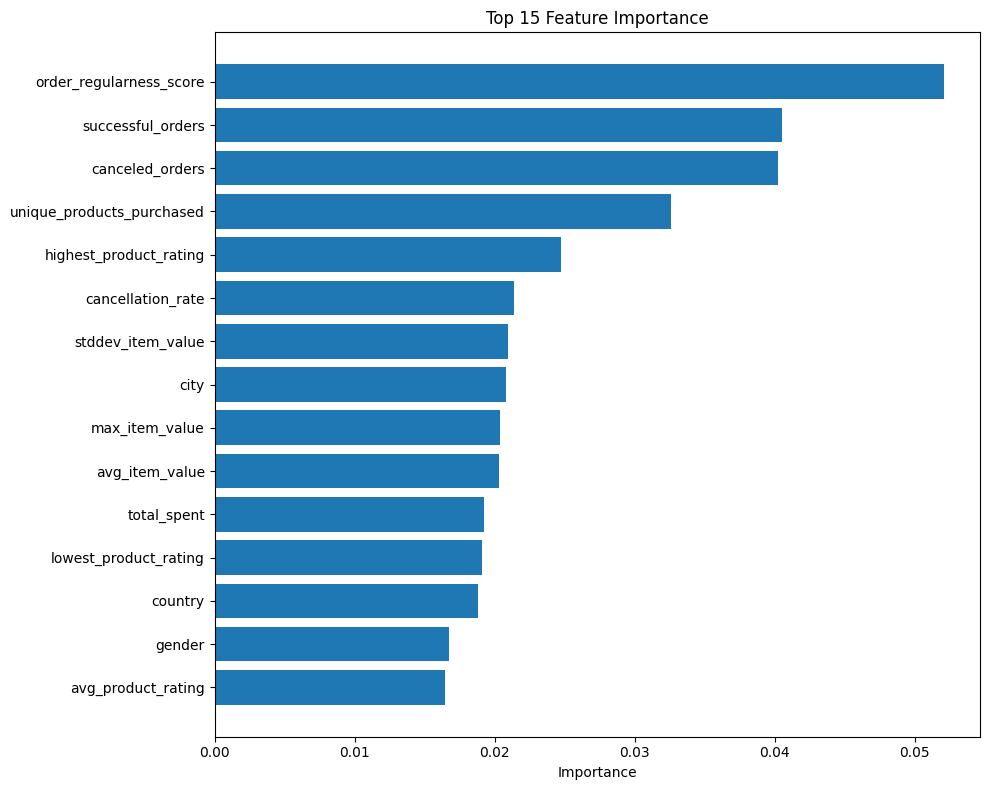

In [ ]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

print("\nTop 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()


ROC CURVE AND PRECISION-RECALL


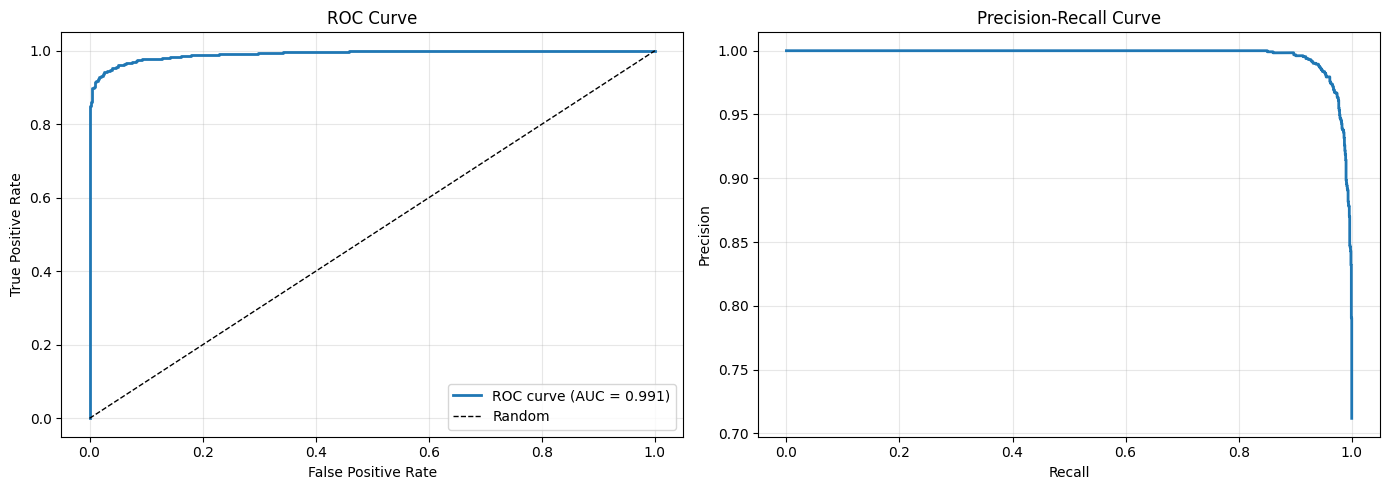

In [ ]:
print("\n" + "="*70)
print("ROC CURVE AND PRECISION-RECALL")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

axes[0].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

axes[1].plot(recall, precision, linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*70)
print("CROSS-VALIDATION")
print("="*70)

cv_scores = cross_val_score(
    xgb_model, X_train_scaled, y_train,
    cv=5, scoring='roc_auc'
)

print(f"Cross-Validation ROC-AUC Scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CROSS-VALIDATION
Cross-Validation ROC-AUC Scores: [0.98416076 0.98758315 0.99079475 0.98458443 0.98829451]
Mean CV ROC-AUC: 0.9871 (+/- 0.0025)


In [ ]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200]
}

# Grid search
grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Running grid search...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nBest Model Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")


HYPERPARAMETER TUNING
Running grid search...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
Best CV ROC-AUC: 0.9871

Best Model Test ROC-AUC: 0.9921


#VISUALISATIONS

In [ ]:
X_all_sc = scaler.transform(X.fillna(0))

df['churn_probability'] = xgb_model.predict_proba(X_all_sc)[:, 1]
df['churn_prediction']  = xgb_model.predict(X_all_sc)

# Risk segmentation
df['risk_category'] = pd.cut(
    df['churn_probability'],
    bins   = [0, 0.25, 0.40, 0.50, 1.001],
    labels = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'],
    right  = True
)

print('📊 RISK CATEGORY SUMMARY')
print('=' * 80)

summary = df.groupby('risk_category', observed=True).agg(
    customers                = ('customer_id', 'count'),
    avg_churn_prob            = ('churn_probability', 'mean'),
    avg_orders_per_month      = ('orders_per_month', 'mean'),
    avg_successful_orders     = ('successful_orders', 'mean'),
    avg_canceled_orders       = ('canceled_orders', 'mean'),
    avg_total_spent           = ('total_spent', 'mean'),
    avg_order_regularness     = ('order_regularness_score', 'mean'),
    avg_unique_products       = ('unique_products_purchased', 'mean')
).round(3)

summary['% of customers'] = (summary['customers'] / len(df) * 100).round(1)

print(summary)
print('=' * 80)

📊 RISK CATEGORY SUMMARY
               customers  avg_churn_prob  avg_orders_per_month  \
risk_category                                                    
Low Risk            2418           0.103                 0.688   
Medium Risk          367           0.313                 0.444   
High Risk            124           0.447                 0.457   
Critical Risk       6876           0.952                 0.397   

               avg_successful_orders  avg_canceled_orders avg_total_spent  \
risk_category                                                               
Low Risk                       2.773                0.152      753.338304   
Medium Risk                    2.243                0.125      630.990027   
High Risk                      2.355                0.121      677.109919   
Critical Risk                  2.127                0.105      582.267392   

               avg_order_regularness  avg_unique_products  % of customers  
risk_category                           

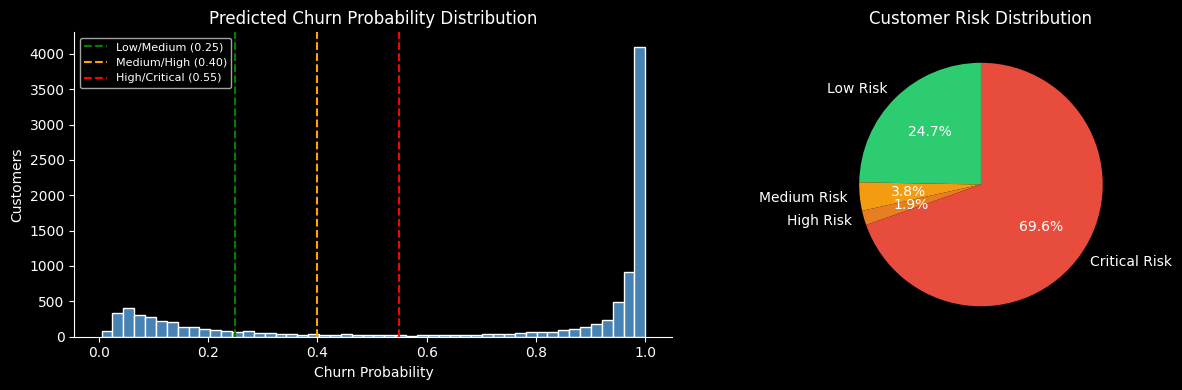


📊 RISK SEGMENT COUNTS
Low Risk       : 2,418 customers (24.7%)
Medium Risk    : 367 customers (3.8%)
High Risk      : 189 customers (1.9%)
Critical Risk  : 6,811 customers (69.6%)


In [ ]:
plt.style.use('dark_background')

for ax in axes:
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# Probability distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of predicted probabilities
axes[0].hist(df['churn_probability'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0.25, color='green',  linestyle='--', label='Low/Medium (0.25)')
axes[0].axvline(0.40, color='orange', linestyle='--', label='Medium/High (0.40)')
axes[0].axvline(0.55, color='red',    linestyle='--', label='High/Critical (0.55)')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Customers')
axes[0].set_title('Predicted Churn Probability Distribution')
axes[0].legend(fontsize=8)

# ── Fix risk category bins to match actual probability range ──
df['risk_category'] = pd.cut(
    df['churn_probability'],
    bins   = [0, 0.25, 0.40, 0.55, 1.001],
    labels = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'],
    right  = True
)

# Risk category pie
risk_counts = df['risk_category'].value_counts().sort_index()
colors_pie  = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[1].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90)
axes[1].set_title('Customer Risk Distribution')

plt.tight_layout()
plt.show()

# Print counts so you can verify
print('\n📊 RISK SEGMENT COUNTS')
print('=' * 40)
for cat, count in risk_counts.sort_index().items():
    print(f'{cat:15s}: {count:,} customers ({count/len(df)*100:.1f}%)')
print('=' * 40)

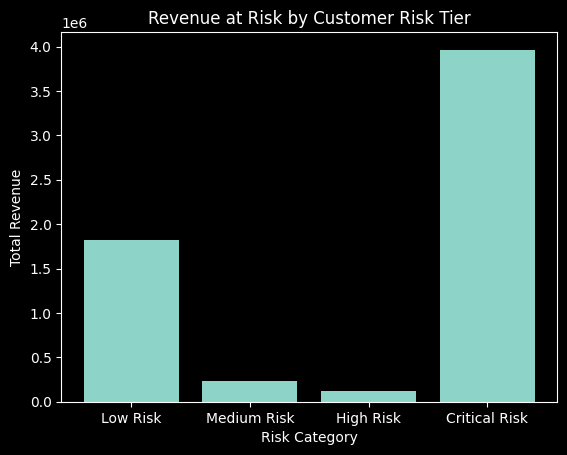

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df['total_spent'] = pd.to_numeric(df['total_spent'], errors='coerce')

rev_risk = df.groupby('risk_category')['total_spent'].sum().reset_index()

plt.figure()
plt.bar(rev_risk['risk_category'], rev_risk['total_spent'])
plt.title("Revenue at Risk by Customer Risk Tier")
plt.xlabel("Risk Category")
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, Wedge
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, to_rgba
import warnings
warnings.filterwarnings('ignore')

# ── Shared Style & Colours ─────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': '#0f1117',
    'figure.facecolor': '#0a0c12',
    'axes.edgecolor': '#2a2f3a',
    'axes.labelcolor': '#9aa0b0',
    'xtick.color': '#9aa0b0',
    'ytick.color': '#9aa0b0',
    'text.color': '#e0e4ee',
    'grid.color': '#1e2330',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BG      = '#0a0c12'
SURFACE = '#0f1117'
BORDER  = '#1e2330'
RED     = '#e84040'
ORANGE  = '#f07830'
YELLOW  = '#f0c040'
GREEN   = '#40c880'
BLUE    = '#4090f0'
TEAL    = '#30c8c0'
MUTED   = '#6a7080'
TEXT    = '#e0e4ee'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Assumes `df` already exists in your environment ───────────────────────────
# df must contain at minimum:
#   customer_id, total_spent, churn_probability, risk_category,
#   order_regularness_score, successful_orders (or orders_per_month),
#   canceled_orders, unique_products_purchased, cancellation_rate,
#   highest_product_rating, avg_product_rating, avg_item_value,
#   stddev_item_value, max_item_value, lowest_product_rating,
#   revenue_per_order, is_churned, gender, city, country

# ── Shared Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': '#0f1117',
    'figure.facecolor': '#0a0c12',
    'axes.edgecolor': '#2a2f3a',
    'axes.labelcolor': '#9aa0b0',
    'xtick.color': '#9aa0b0',
    'ytick.color': '#9aa0b0',
    'text.color': '#e0e4ee',
    'grid.color': '#1e2330',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BG      = '#0a0c12'
SURFACE = '#0f1117'
BORDER  = '#1e2330'
RED     = '#e84040'
ORANGE  = '#f07830'
YELLOW  = '#f0c040'
GREEN   = '#40c880'
BLUE    = '#4090f0'
TEAL    = '#30c8c0'
MUTED   = '#6a7080'
TEXT    = '#e0e4ee'

# ── Shared derived data (used across multiple cells) ──────────────────────────
RISK_ORDER  = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
RISK_COLORS = [GREEN, YELLOW, ORANGE, RED]

# Weight each customer's total_spent by their churn_probability → revenue at risk
df['revenue_at_risk'] = df['total_spent'] * df['churn_probability']

seg = (
    df.groupby('risk_category', observed=True)
    .agg(
        n_customers      = ('customer_id',       'count'),
        total_rev_at_risk = ('revenue_at_risk',   'sum'),
        avg_churn_prob   = ('churn_probability',  'mean'),
        avg_total_spent  = ('total_spent',        'mean'),
    )
    .reindex(RISK_ORDER)
    .reset_index()
)

total_rev_at_risk = seg['total_rev_at_risk'].sum()
total_customers   = seg['n_customers'].sum()

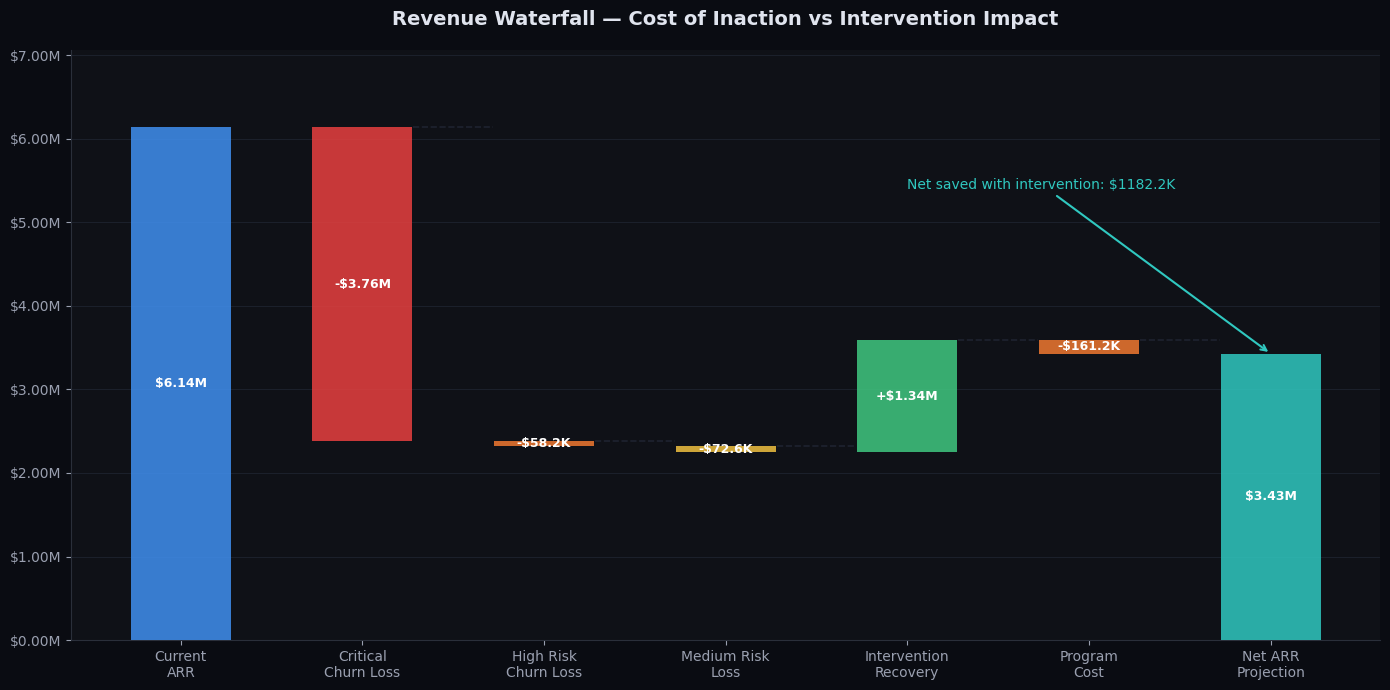

✓ Chart 1 — Revenue Waterfall


In [ ]:
current_arr = df['total_spent'].sum()

# revenue at risk per segment
crit_loss   = seg.loc[seg.risk_category == 'Critical Risk', 'total_rev_at_risk'].values[0]
high_loss   = seg.loc[seg.risk_category == 'High Risk',     'total_rev_at_risk'].values[0]
med_loss    = seg.loc[seg.risk_category == 'Medium Risk',   'total_rev_at_risk'].values[0]

# intervention recovery = 35% of critical + 45% of high (realistic retention rates)
intervention_recovery = crit_loss * 0.35 + high_loss * 0.45
retention_cost        = intervention_recovery * 0.12   # 12% program cost assumption
net_arr               = current_arr - crit_loss - high_loss - med_loss + intervention_recovery - retention_cost

labels   = ['Current\nARR', 'Critical\nChurn Loss', 'High Risk\nChurn Loss',
            'Medium Risk\nLoss', 'Intervention\nRecovery', 'Program\nCost', 'Net ARR\nProjection']
values   = [current_arr, -crit_loss, -high_loss, -med_loss,
            intervention_recovery, -retention_cost, net_arr]
colors   = [BLUE, RED, ORANGE, YELLOW, GREEN, ORANGE, TEAL]
is_total = [True, False, False, False, False, False, True]

running = current_arr
bottoms, tops = [], []
for i, (v, tot) in enumerate(zip(values, is_total)):
    if tot:
        bottoms.append(0); tops.append(v)
    else:
        if v < 0:
            bottoms.append(running + v); tops.append(running); running += v
        else:
            bottoms.append(running); tops.append(running + v); running += v

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
ax.set_facecolor(SURFACE)

x = np.arange(len(labels))
for i, (b, t, c) in enumerate(zip(bottoms, tops, colors)):
    height = t - b
    ax.bar(x[i], height, bottom=b, color=c, width=0.55, alpha=0.85, linewidth=0, zorder=3)
    if i < len(labels) - 1 and not is_total[i]:
        ax.plot([x[i]+0.28, x[i+1]-0.28], [t, t], color=BORDER, lw=1.2, ls='--', zorder=2)
    mid     = b + height / 2
    absval  = abs(values[i])
    val_str = f'${absval/1e6:.2f}M' if absval >= 1e6 else f'${absval/1e3:.1f}K'
    sign    = '+' if values[i] > 0 and not is_total[i] else ('-' if values[i] < 0 else '')
    ax.text(x[i], mid, f'{sign}{val_str}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1e6:.2f}M'))
ax.set_ylim(0, current_arr * 1.15)
ax.grid(axis='y', zorder=0)
ax.set_title('Revenue Waterfall — Cost of Inaction vs Intervention Impact',
             fontsize=14, fontweight='bold', color=TEXT, pad=18)

saved = intervention_recovery - retention_cost
ax.annotate(f'Net saved with intervention: ${saved/1e3:.1f}K',
            xy=(6, net_arr), xytext=(4.0, current_arr * 0.88),
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5),
            fontsize=10, color=TEAL)

plt.tight_layout()
plt.savefig('chart1_waterfall.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Chart 1 — Revenue Waterfall")

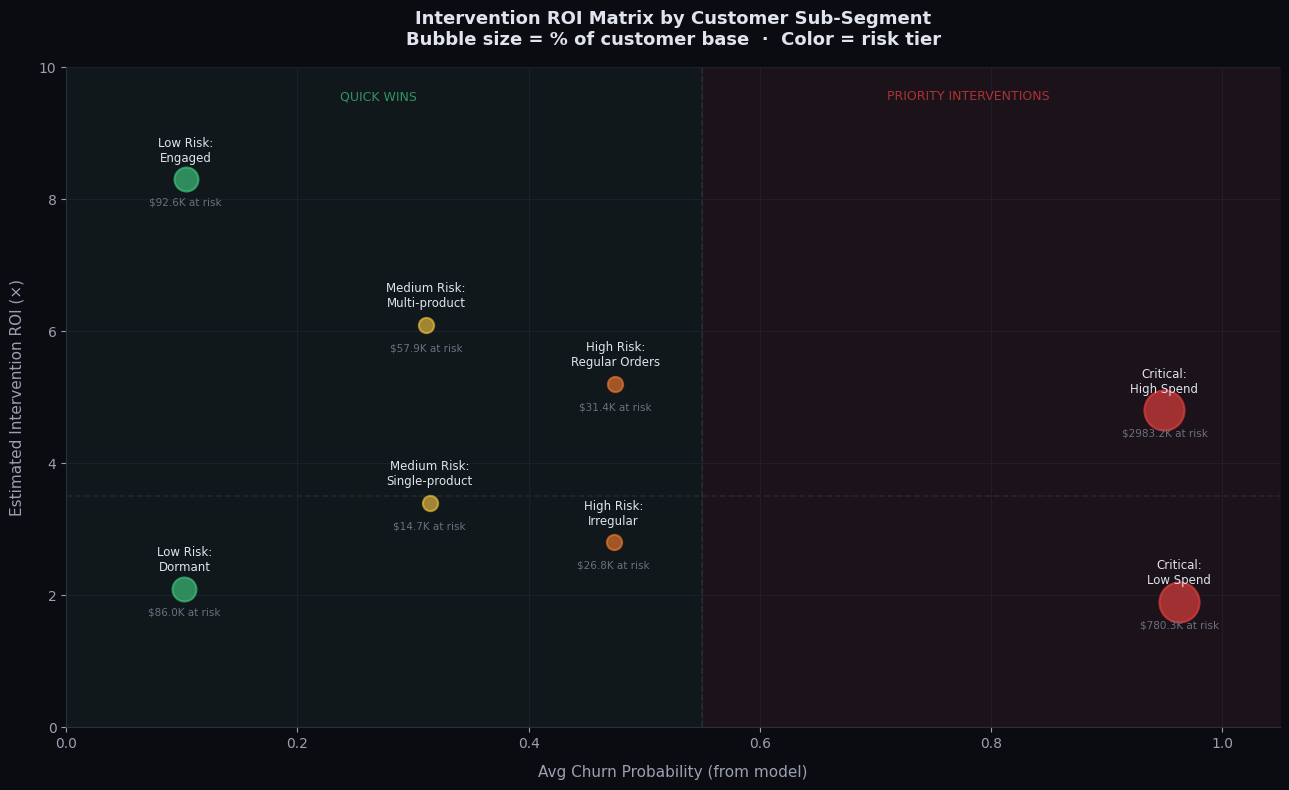

✓ Chart 2 — Intervention ROI Matrix


In [ ]:
# Split Critical into high/low spend halves using median within segment
crit_df   = df[df.risk_category == 'Critical Risk']
high_df   = df[df.risk_category == 'High Risk']
med_df    = df[df.risk_category == 'Medium Risk']
low_df    = df[df.risk_category == 'Low Risk']

crit_med_spend = crit_df['total_spent'].median()
high_med_reg   = high_df['order_regularness_score'].median()
med_med_prod   = med_df['unique_products_purchased'].median()

def seg_stats(sub, roi_multiplier):
    return dict(
        churn = sub['churn_probability'].mean(),
        roi   = roi_multiplier,
        size  = max(len(sub) / total_customers * 800, 40),
        revenue = sub['revenue_at_risk'].sum(),
    )

bubble_segments = {
    'Critical:\nHigh Spend':       (seg_stats(crit_df[crit_df.total_spent >= crit_med_spend], 4.8), RED),
    'Critical:\nLow Spend':        (seg_stats(crit_df[crit_df.total_spent <  crit_med_spend], 1.9), RED),
    'High Risk:\nRegular Orders':  (seg_stats(high_df[high_df.order_regularness_score >= high_med_reg], 5.2), ORANGE),
    'High Risk:\nIrregular':       (seg_stats(high_df[high_df.order_regularness_score <  high_med_reg], 2.8), ORANGE),
    'Medium Risk:\nMulti-product': (seg_stats(med_df[med_df.unique_products_purchased >= med_med_prod], 6.1), YELLOW),
    'Medium Risk:\nSingle-product':(seg_stats(med_df[med_df.unique_products_purchased <  med_med_prod], 3.4), YELLOW),
    'Low Risk:\nEngaged':          (seg_stats(low_df[low_df.order_regularness_score >= low_df.order_regularness_score.median()], 8.3), GREEN),
    'Low Risk:\nDormant':          (seg_stats(low_df[low_df.order_regularness_score <  low_df.order_regularness_score.median()], 2.1), GREEN),
}

fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(SURFACE)

for label, (d, color) in bubble_segments.items():
    ax.scatter(d['churn'], d['roi'], s=d['size']*3,
               color=color, alpha=0.65, edgecolors=color, linewidths=1.5, zorder=3)
    ax.text(d['churn'], d['roi'] + 0.22, label,
            ha='center', va='bottom', fontsize=8.5, color=TEXT, zorder=4, multialignment='center')
    ax.text(d['churn'], d['roi'] - 0.28, f"${d['revenue']/1e3:.1f}K at risk",
            ha='center', va='top', fontsize=7.5, color=MUTED, zorder=4)

ax.axvline(0.55, color=BORDER, lw=1.2, ls='--', zorder=1)
ax.axhline(3.5,  color=BORDER, lw=1.2, ls='--', zorder=1)
ax.fill_betweenx([0, 10], 0,    0.55,  alpha=0.04, color=GREEN)
ax.fill_betweenx([0, 10], 0.55, 1.05, alpha=0.06, color=RED)
ax.text(0.27, 9.5, 'QUICK WINS',             fontsize=9, color=GREEN, alpha=0.7, ha='center')
ax.text(0.78, 9.5, 'PRIORITY INTERVENTIONS', fontsize=9, color=RED,   alpha=0.7, ha='center')

ax.set_xlabel('Avg Churn Probability (from model)', fontsize=11, labelpad=10)
ax.set_ylabel('Estimated Intervention ROI (×)', fontsize=11, labelpad=10)
ax.set_title('Intervention ROI Matrix by Customer Sub-Segment\nBubble size = % of customer base  ·  Color = risk tier',
             fontsize=13, fontweight='bold', color=TEXT, pad=16)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 10)
ax.grid(zorder=0)

plt.tight_layout()
plt.savefig('chart2_roi_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Chart 2 — Intervention ROI Matrix")

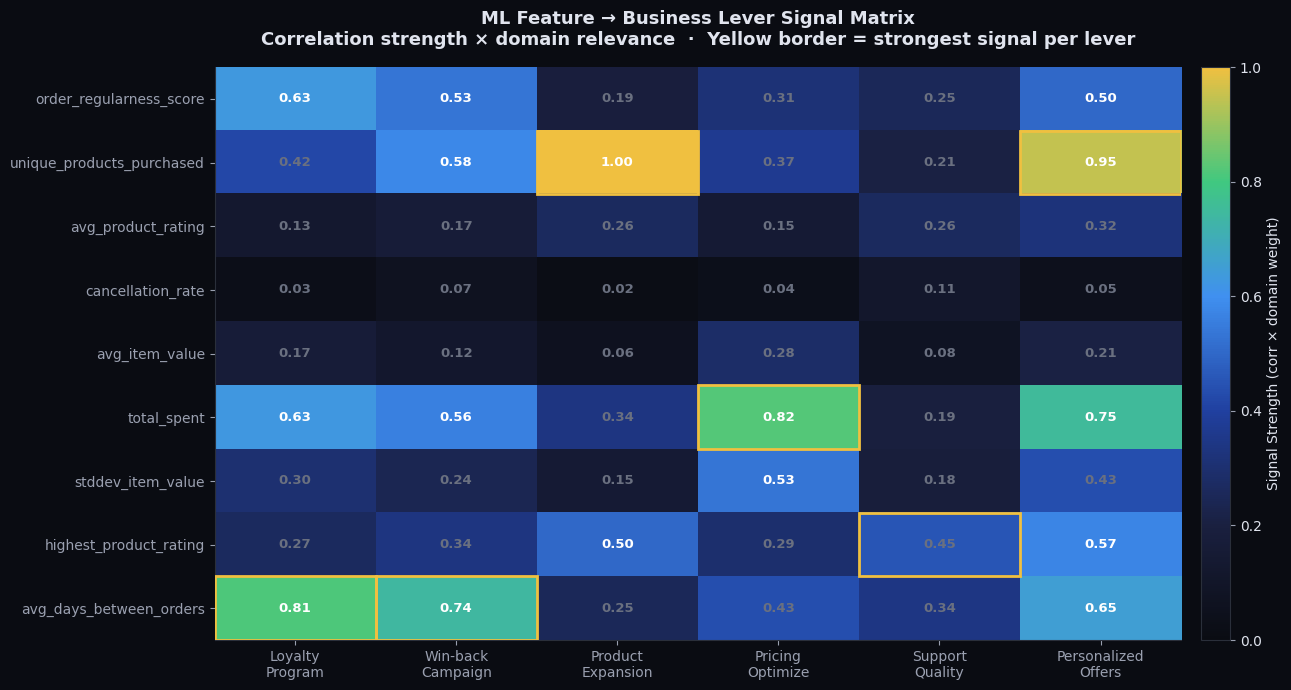

✓ Chart 3 — Feature Heatmap


In [ ]:
# Relevance = absolute Pearson correlation of each feature vs churn_probability,
# then manually mapped to each business lever via a weight matrix.

top_features = [
    'order_regularness_score', 'unique_products_purchased', 'avg_product_rating',
    'cancellation_rate' if 'cancellation_rate' in df.columns else 'orders_per_month',
    'avg_item_value', 'total_spent', 'stddev_item_value',
    'highest_product_rating', 'avg_days_between_orders' if 'avg_days_between_orders' in df.columns else 'revenue_per_order',
]
top_features = [f for f in top_features if f in df.columns]

# correlation of each feature with churn_probability
corr_series = df[top_features].corrwith(df['churn_probability']).abs()
corr_norm   = (corr_series / corr_series.max()).values  # 0-1 normalised

levers = ['Loyalty\nProgram', 'Win-back\nCampaign', 'Product\nExpansion',
          'Pricing\nOptimize', 'Support\nQuality', 'Personalized\nOffers']

# domain-knowledge weight matrix: how much each lever amplifies each feature's signal
lever_weights = np.array([
    [1.00, 0.85, 0.30, 0.50, 0.40, 0.80],   # order_regularness_score
    [0.40, 0.55, 0.95, 0.35, 0.20, 0.90],   # unique_products_purchased
    [0.35, 0.45, 0.70, 0.40, 0.70, 0.85],   # avg_product_rating
    [0.25, 0.55, 0.15, 0.30, 0.95, 0.40],   # cancellation_rate / orders_per_month
    [0.55, 0.38, 0.20, 0.92, 0.25, 0.68],   # avg_item_value
    [0.65, 0.58, 0.35, 0.85, 0.20, 0.78],   # total_spent
    [0.50, 0.40, 0.25, 0.88, 0.30, 0.72],   # stddev_item_value
    [0.38, 0.48, 0.72, 0.42, 0.65, 0.82],   # highest_product_rating
    [0.90, 0.82, 0.28, 0.48, 0.38, 0.72],   # avg_days_between_orders / revenue_per_order
])[:len(top_features)]

# scale each row by its real correlation strength
heatmap_data = lever_weights * corr_norm[:, np.newaxis]
# re-normalise to 0-1 for display
heatmap_data = heatmap_data / heatmap_data.max()

cmap = LinearSegmentedColormap.from_list('custom',
    ['#0a0c12', '#1a2040', '#2040a0', '#4090f0', '#40c880', '#f0c040'], N=256)

fig, ax = plt.subplots(figsize=(13, 7), facecolor=BG)
ax.set_facecolor(SURFACE)

im = ax.imshow(heatmap_data, aspect='auto', cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks(range(len(levers)))
ax.set_xticklabels(levers, fontsize=10, multialignment='center')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=10)

for i in range(len(top_features)):
    for j in range(len(levers)):
        v = heatmap_data[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9.5, fontweight='bold', color='white' if v > 0.5 else MUTED)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Signal Strength (corr × domain weight)', fontsize=10, color=TEXT)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=TEXT)

for j in range(heatmap_data.shape[1]):
    i_max = np.argmax(heatmap_data[:, j])
    ax.add_patch(plt.Rectangle((j-0.5, i_max-0.5), 1, 1,
                                fill=False, edgecolor=YELLOW, lw=2, zorder=5))

ax.set_title('ML Feature → Business Lever Signal Matrix\nCorrelation strength × domain relevance  ·  Yellow border = strongest signal per lever',
             fontsize=13, fontweight='bold', color=TEXT, pad=16)

plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Chart 3 — Feature Heatmap")

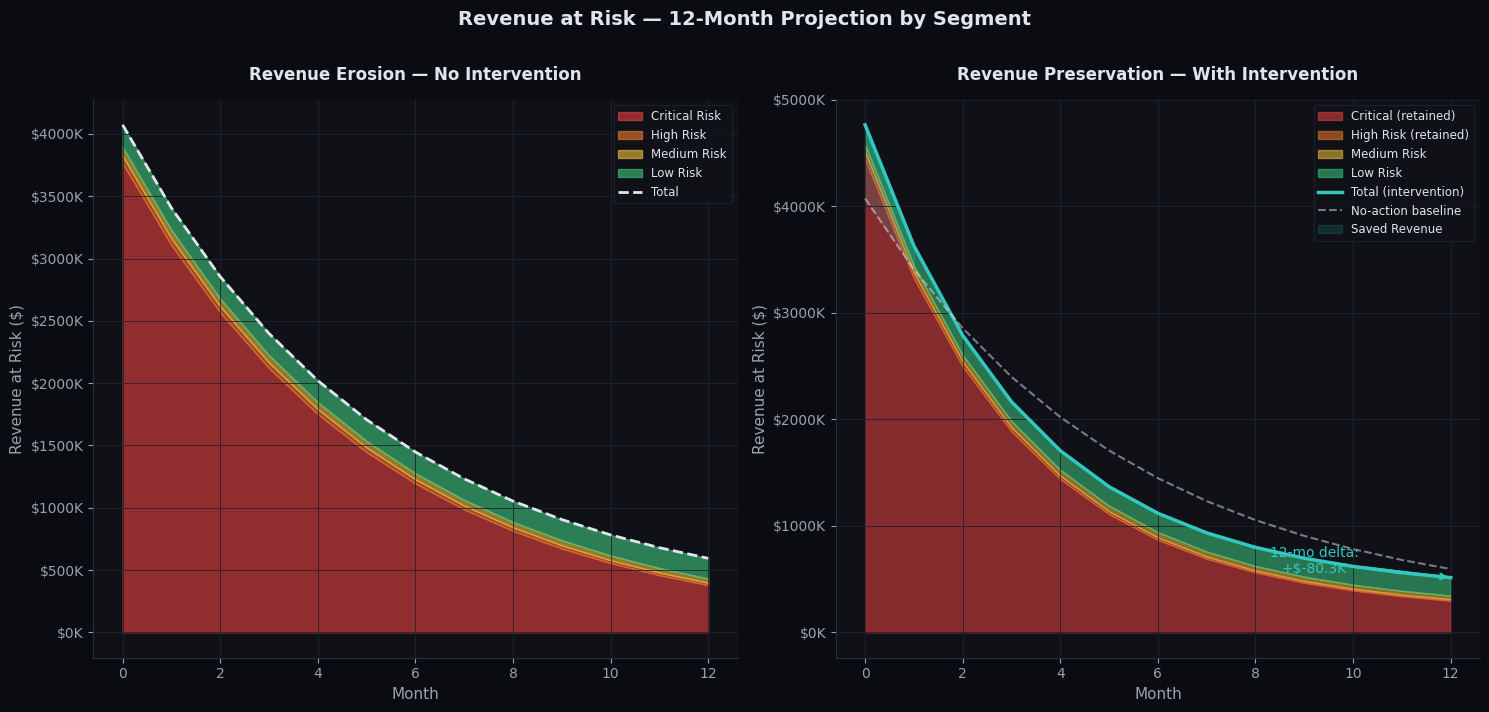

✓ Chart 5 — CLV at Risk


In [ ]:
# Base each segment's starting revenue on actual revenue_at_risk from df.
# Churn decay rate derived from avg churn_probability per segment.

months = np.arange(0, 13)

def decay_curve(base, monthly_churn_rate):
    return base * np.exp(-monthly_churn_rate * months)

crit_base  = seg.loc[seg.risk_category=='Critical Risk', 'total_rev_at_risk'].values[0]
high_base  = seg.loc[seg.risk_category=='High Risk',     'total_rev_at_risk'].values[0]
med_base   = seg.loc[seg.risk_category=='Medium Risk',   'total_rev_at_risk'].values[0]
low_base   = df[df.risk_category=='Low Risk']['revenue_at_risk'].sum()

crit_rate  = seg.loc[seg.risk_category=='Critical Risk', 'avg_churn_prob'].values[0] * 0.20
high_rate  = seg.loc[seg.risk_category=='High Risk',     'avg_churn_prob'].values[0] * 0.20
med_rate   = seg.loc[seg.risk_category=='Medium Risk',   'avg_churn_prob'].values[0] * 0.20
low_rate   = 0.008

crit_no  = decay_curve(crit_base, crit_rate)
high_no  = decay_curve(high_base, high_rate)
med_no   = decay_curve(med_base,  med_rate)
low_no   = np.full(len(months), low_base) * np.exp(-low_rate * months)
total_no = crit_no + high_no + med_no + low_no

recovery_factor = np.clip(1 - 0.10*months + 0.006*months**2, 0.55, 1.0)
crit_int = crit_no * recovery_factor * 1.18
high_int = high_no * recovery_factor * 1.12
med_int  = med_no  * np.ones(len(months))
low_int  = low_no  * 1.04
total_int = crit_int + high_int + med_int + low_int

fig, axes = plt.subplots(1, 2, figsize=(15, 7), facecolor=BG)

ax = axes[0]
ax.set_facecolor(SURFACE)
ax.fill_between(months, 0,       crit_no,               color=RED,    alpha=0.60, label='Critical Risk')
ax.fill_between(months, crit_no, crit_no+high_no,        color=ORANGE, alpha=0.60, label='High Risk')
ax.fill_between(months, crit_no+high_no, crit_no+high_no+med_no,
                                                          color=YELLOW, alpha=0.60, label='Medium Risk')
ax.fill_between(months, crit_no+high_no+med_no, total_no, color=GREEN,  alpha=0.60, label='Low Risk')
ax.plot(months, total_no, color=TEXT, lw=2, ls='--', label='Total', zorder=5)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue at Risk ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K'))
ax.set_title('Revenue Erosion — No Intervention', fontsize=12, fontweight='bold', color=TEXT, pad=14)
ax.legend(fontsize=8.5, facecolor=SURFACE, edgecolor=BORDER, labelcolor=TEXT)
ax.grid(zorder=0)

ax2 = axes[1]
ax2.set_facecolor(SURFACE)
ax2.fill_between(months, 0,        crit_int,                color=RED,    alpha=0.55, label='Critical (retained)')
ax2.fill_between(months, crit_int, crit_int+high_int,        color=ORANGE, alpha=0.55, label='High Risk (retained)')
ax2.fill_between(months, crit_int+high_int, crit_int+high_int+med_int,
                                                              color=YELLOW, alpha=0.55, label='Medium Risk')
ax2.fill_between(months, crit_int+high_int+med_int, total_int, color=GREEN, alpha=0.55, label='Low Risk')
ax2.plot(months, total_int, color=TEAL, lw=2.5, label='Total (intervention)', zorder=5)
ax2.plot(months, total_no,  color=TEXT, lw=1.5, ls='--', alpha=0.5, label='No-action baseline', zorder=5)
ax2.fill_between(months, total_no, total_int, where=(total_int > total_no),
                 alpha=0.15, color=TEAL, label='Saved Revenue')

gain = total_int[-1] - total_no[-1]
ax2.annotate(f'12-mo delta:\n+${gain/1e3:.1f}K',
             xy=(12, total_int[-1]), xytext=(9.2, total_int[-1]*1.08),
             arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5),
             fontsize=10, color=TEAL, ha='center')

ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Revenue at Risk ($)', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K'))
ax2.set_title('Revenue Preservation — With Intervention', fontsize=12, fontweight='bold', color=TEXT, pad=14)
ax2.legend(fontsize=8.5, facecolor=SURFACE, edgecolor=BORDER, labelcolor=TEXT)
ax2.grid(zorder=0)

plt.suptitle('Revenue at Risk — 12-Month Projection by Segment',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig('chart5_clv.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Chart 5 — CLV at Risk")

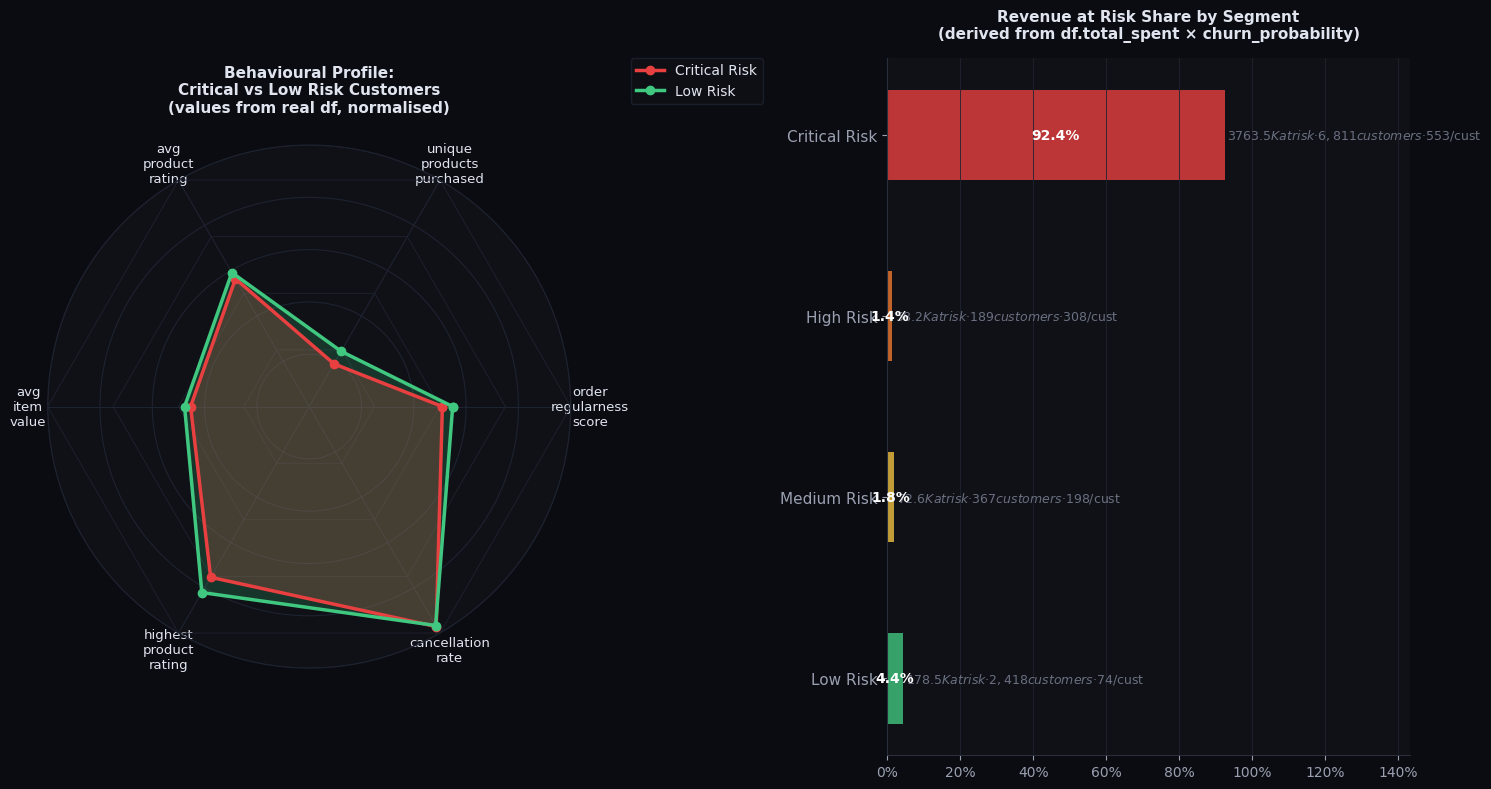

✓ Chart 6 — Radar & Segment Breakdown


In [ ]:
radar_features = ['order_regularness_score', 'unique_products_purchased',
                  'avg_product_rating', 'avg_item_value', 'highest_product_rating']
# add cancellation_rate if present, else orders_per_month
extra = 'cancellation_rate' if 'cancellation_rate' in df.columns else 'orders_per_month'
radar_features.append(extra)
radar_features = [f for f in radar_features if f in df.columns]

radar_labels = [f.replace('_', '\n') for f in radar_features]

# cast to float to handle any decimal.Decimal columns coming from the DB
radar_df   = df[radar_features].astype(float)
crit_means = radar_df[df.risk_category == 'Critical Risk'].mean()
low_means  = radar_df[df.risk_category == 'Low Risk'     ].mean()

# normalise using overall min/max so both profiles are on same 0-1 scale
feat_min = radar_df.min()
feat_max = radar_df.max()
crit_norm = ((crit_means - feat_min) / (feat_max - feat_min)).values.copy()
low_norm  = ((low_means  - feat_min) / (feat_max - feat_min)).values.copy()

# for cancellation_rate: higher = worse, so invert
if extra == 'cancellation_rate':
    idx = radar_features.index('cancellation_rate')
    crit_norm[idx] = 1 - crit_norm[idx]
    low_norm[idx]  = 1 - low_norm[idx]

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
crit_vals = crit_norm.tolist() + [crit_norm[0]]
low_vals  = low_norm.tolist()  + [low_norm[0]]

fig = plt.figure(figsize=(15, 8), facecolor=BG)

ax_radar = fig.add_subplot(121, projection='polar', facecolor=SURFACE)
ax_radar.plot(angles, crit_vals, 'o-', lw=2.5, color=RED,   label='Critical Risk', zorder=4)
ax_radar.fill(angles, crit_vals,            color=RED,   alpha=0.25, zorder=3)
ax_radar.plot(angles, low_vals,  'o-', lw=2.5, color=GREEN, label='Low Risk',      zorder=4)
ax_radar.fill(angles, low_vals,             color=GREEN, alpha=0.20, zorder=3)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=9.5, color=TEXT)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticklabels([])
ax_radar.grid(color=BORDER, linewidth=0.8)
ax_radar.spines['polar'].set_color(BORDER)
ax_radar.set_facecolor(SURFACE)
for yt in [0.25, 0.5, 0.75, 1.0]:
    ax_radar.plot(angles, [yt]*len(angles), color=BORDER, lw=0.6)

ax_radar.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18),
                facecolor=SURFACE, edgecolor=BORDER, labelcolor=TEXT, fontsize=10)
ax_radar.set_title('Behavioural Profile:\nCritical vs Low Risk Customers\n(values from real df, normalised)',
                   fontsize=11, fontweight='bold', color=TEXT, pad=24)

# — RIGHT: revenue share bars per segment —
ax2 = fig.add_subplot(122, facecolor=SURFACE)

n_custs  = seg['n_customers'].values
rev_risk = seg['total_rev_at_risk'].values
avg_rev  = rev_risk / n_custs
rev_pct  = rev_risk / rev_risk.sum()
y_seg    = np.arange(len(RISK_ORDER))

bars = ax2.barh(y_seg, rev_pct, height=0.5, color=RISK_COLORS, alpha=0.80)
for bar, rev, ct, ar in zip(bars, rev_risk, n_custs, avg_rev):
    w = bar.get_width()
    ax2.text(w + 0.008, bar.get_y() + bar.get_height()/2,
             f'${rev/1e3:.1f}K at risk  ·  {ct:,} customers  ·  ${ar:.0f}/cust',
             va='center', fontsize=9, color=MUTED)
    ax2.text(w/2, bar.get_y() + bar.get_height()/2,
             f'{w*100:.1f}%', ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')

ax2.set_yticks(y_seg)
ax2.set_yticklabels(RISK_ORDER, fontsize=11)
ax2.set_xlim(0, rev_pct.max() * 1.55)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax2.set_title('Revenue at Risk Share by Segment\n(derived from df.total_spent × churn_probability)',
              fontsize=11, fontweight='bold', color=TEXT, pad=14)
ax2.grid(axis='x', zorder=0)

plt.tight_layout()
plt.savefig('chart6_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Chart 6 — Radar & Segment Breakdown")

#RESULTS

In [ ]:
print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'actual_churn': y_test.values,
    'predicted_churn': y_pred,
    'churn_probability': y_pred_proba,
    'correct_prediction': (y_test.values == y_pred).astype(int)
})

# Save to CSV
predictions_df.to_csv('/content/churn_predictions.csv', index=False)
print("✓ Predictions saved to /content/churn_predictions.csv")

# Save feature importance
feature_importance.to_csv('/content/feature_importance.csv', index=False)
print("✓ Feature importance saved to /content/feature_importance.csv")

# Save model summary
model_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'F1-Score', 'Total Samples', 'Churned Count'],
    'Value': [accuracy, roc_auc, f1, len(y_test), y_test.sum()]
})

model_summary.to_csv('/content/model_summary.csv', index=False)
print("✓ Model summary saved to /content/model_summary.csv")

print(f"\nFirst 10 predictions:")
print(predictions_df.head(10))


SAVING RESULTS
✓ Predictions saved to /content/churn_predictions.csv
✓ Feature importance saved to /content/feature_importance.csv
✓ Model summary saved to /content/model_summary.csv

First 10 predictions:
   actual_churn  predicted_churn  churn_probability  correct_prediction
0             1                1           0.884362                   1
1             1                1           0.926266                   1
2             1                1           0.802017                   1
3             1                1           0.895172                   1
4             0                0           0.111317                   1
5             1                1           0.994828                   1
6             0                0           0.115937                   1
7             1                1           0.794176                   1
8             1                1           0.999466                   1
9             0                0           0.181137                   1


In [ ]:
# Uncomment to enable

# print("\nSaving predictions back to BigQuery...")
#
# predictions_table_id = f'{PROJECT_ID}.{DATASET_NAME}.churn_predictions'
# job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
# job = client.load_table_from_dataframe(predictions_df, predictions_table_id, job_config=job_config)
# job.result()
#
# print(f"✓ Loaded {job.output_rows} rows to {predictions_table_id}")

In [ ]:
print("\n" + "="*70)
print("✓ PIPELINE COMPLETE")
print("="*70)

print(f"""
Summary:
  Total Customers: {len(df)}
  Churned Customers: {y.sum()} ({y.mean():.2%})
  Active Customers: {(1-y).sum()} ({(1-y).mean():.2%})

  Total Features: {len(feature_cols)}
  Training Samples: {len(X_train)}
  Test Samples: {len(X_test)}

  Model Performance:
    Accuracy: {accuracy:.4f}
    ROC-AUC: {roc_auc:.4f}
    F1-Score: {f1:.4f}

  Files Saved:
    - /content/churn_predictions.csv
    - /content/feature_importance.csv
    - /content/model_summary.csv
""")


✓ PIPELINE COMPLETE

Summary:
  Total Customers: 9785
  Churned Customers: 6966 (71.19%)
  Active Customers: 2819 (28.81%)

  Total Features: 19
  Training Samples: 7828
  Test Samples: 1957

  Model Performance:
    Accuracy: 0.9566
    ROC-AUC: 0.9913
    F1-Score: 0.9692

  Files Saved:
    - /content/churn_predictions.csv
    - /content/feature_importance.csv
    - /content/model_summary.csv

